# Intraday Probability Band Engine

## Backtest Research Notebook

This notebook is the main research and backtesting workspace for the probability band engine.

It loads historical intraday data, applies the reusable `src/` modules, and evaluates VWAP / TWAP reference lines, sigma bands, z-score zones, outcome labels, and empirical probability tables.

The project is structured so that:
- reusable engine logic lives in `src/`
- research, diagnostics, and charts live in this notebook
- live monitoring and trading workflow live in `notebooks/live_trading.ipynb`

---

## What this notebook does

1. Loads and inspects historical intraday data
2. Checks data quality and session structure
3. Computes the intraday reference line
4. Builds sigma bands and z-score zones
5. Extracts context variables
6. Labels historical outcomes
7. Calibrates empirical conditional probabilities
8. Runs backtest analysis and diagnostics
9. Produces charts, tables, and research outputs

---
### Section 0 — Imports and Global Configuration

All dependencies are imported once here. The `CONFIG` dictionary is the **single place
you change parameters** — instrument, file paths, band thresholds, outcome horizon.
Nothing below this cell contains magic numbers.

In [13]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("✅ Project root added to Python path:")
print(PROJECT_ROOT)

✅ Project root added to Python path:
c:\Users\k2587979\Documents\GitHub Projects\VWAP-probability-band-engine\VWAP-probability-band-engine


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [40]:
from src.config import CONFIG
from src.loaders import load_mt5_csv, load_mt5_live, load_tradingview_csv, load_generic_csv, assign_sessions
from src.reference import compute_reference
from src.sigma import compute_sigma, compute_bands
from src.zones import ZONE_LABELS, ZONE_COLORS, compute_zscore, classify_zone, classify_zones_series
from src.context import compute_context
from src.labelling import label_outcomes
from src.splits import split_by_date
from src.calibration import wilson_ci, calibrate_probability_table
from src.lookup import lookup_probabilities
from src.signals import SignalResult, generate_signal, regime_gate, apply_filters
from src.walk_forward import walk_forward_eval
from src.evaluation import evaluate_signals, run_backtest
from src.plotting import plot_band_overlay, plot_probability_heatmap
from src.exports import save_artefacts, export_live_artefacts
from src.engine import EngineState, update_engine_state

In [23]:
import importlib
import src.config
importlib.reload(src.config)
from src.config import CONFIG

print("✅ Fresh CONFIG loaded")
print(CONFIG.get('data_dir', 'no data_dir key'))
print(CONFIG.get('csv_filename', 'no csv_filename key'))

✅ Fresh CONFIG loaded
C:\Users\k2587979\Documents\GitHub Projects\VWAP-probability-band-engine\VWAP-probability-band-engine\data\historical
US100_cash_M1_NY_session_30d.csv


In [24]:
print("✅ Configuration loaded")
print(f"   Instrument : {CONFIG['instrument']}")
print(f"   Reference  : {CONFIG['reference_type']}")
print(f"   Vol method : {CONFIG['vol_method']}")
print(f"   Horizon    : {CONFIG['outcome_horizon_bars']} bars")
print(f"   Spread     : {CONFIG['spread_cost']} price units")
print(f"   Edge gap   : {CONFIG['edge_gap_threshold']:.0%} minimum")

✅ Configuration loaded
   Instrument : US100.cash
   Reference  : VWAP
   Vol method : ewma
   Horizon    : 12 bars
   Spread     : 0.8 price units
   Edge gap   : 10% minimum


---
### Section 1 — Data Normalisation Layer

This is the **only part of the project that knows anything about a specific data source**.
Every loader function below produces an identical output DataFrame with columns:

| Column | Type | Description |
|--------|------|-------------|
| `timestamp` | DatetimeTZ (UTC) | Bar open time |
| `open` | float | Open price |
| `high` | float | High price |
| `low` | float | Low price |
| `close` | float | Close price |
| `volume` | float | Tick volume (proxy for real volume) |
| `typical_price` | float | (H+L+C)/3 — pre-computed for VWAP |
| `session_date` | date | The trading date (for VWAP daily reset) |

Once data passes through a loader, **all downstream code is source-agnostic**.
To add a new source (e.g. Binance, IB, dxFeed), write one new loader function
that outputs this same schema — nothing else changes.# Section 1 — Data Loading and Basic Inspection

In [17]:
# ── Load data — change loader here if your source changes ──
csv_path = CONFIG['data_dir'] / CONFIG['csv_filename']
df = load_mt5_csv(str(csv_path))

# ── Basic inspection ──
print(f"\nDate range  : {df['datetime'].iloc[0]} → {df['datetime'].iloc[-1]}")
print(f"Total bars  : {len(df):,}")
print(f"Unique days : {df['session_date'].nunique()}")
print(f"\nColumn dtypes:")
print(df.dtypes)
print(f"\nFirst 3 rows:")
df.head(3)

✅ MT5 CSV loaded: 6,728 bars from C:\Users\k2587979\Documents\GitHub Projects\VWAP-probability-band-engine\VWAP-probability-band-engine\data\historical\US100_cash_M1_NY_session_30d.csv

Date range  : 2026-01-29 15:22:00+00:00 → 2026-03-17 16:29:00+00:00
Total bars  : 6,728
Unique days : 34

Column dtypes:
datetime         datetime64[us, UTC]
open                         float64
high                         float64
low                          float64
close                        float64
tick_volume                    int64
typical_price                float64
session_date                  object
dtype: object

First 3 rows:


,datetime,open,high,low,close,tick_volume,typical_price,session_date
0,2026-01-29 15:22:00+00:00,26033.45,26035.15,26027.95,26034.55,261,26032.550000,2026-01-29
1,2026-01-29 15:23:00+00:00,26034.45,26037.55,26032.15,26034.25,234,26034.650000,2026-01-29
2,2026-01-29 15:24:00+00:00,26034.45,26040.05,26034.45,26040.05,234,26038.183333,2026-01-29


### Section 2 — Data Quality Checks

In [18]:
# ── Data quality checks ──
issues = []

zero_vol = (df['tick_volume'] <= 1.0).sum()
if zero_vol > len(df) * 0.05:
    issues.append(f"⚠️  {zero_vol:,} bars ({zero_vol/len(df):.1%}) have volume ≤ 1 — VWAP may be unreliable")

null_count = df.isnull().sum().sum()
if null_count > 0:
    issues.append(f"⚠️  {null_count} null values found — check loader output")

# Detect time gaps larger than expected bar duration
time_diffs = df['datetime'].diff().dropna()
median_diff = time_diffs.median()
large_gaps = (time_diffs > median_diff * 3).sum()
if large_gaps > 0:
    issues.append(f"⚠️  {large_gaps} time gaps > 3x bar duration (weekends/news expected)")

if issues:
    for i in issues:
        print(i)
else:
    print("✅ Data quality checks passed")

print(f"\nMedian bar duration: {median_diff}")
print(f"Volume stats:\n{df['tick_volume'].describe().round(2)}")

⚠️  33 time gaps > 3x bar duration (weekends/news expected)

Median bar duration: 0 days 00:01:00
Volume stats:
count    6728.00
mean      342.77
std       126.27
min        86.00
25%       244.00
50%       315.00
75%       454.25
max       590.00
Name: tick_volume, dtype: float64


---
### Section 3 — VWAP / Mean Reference Calculation

VWAP is computed **per session** — it resets to zero at the start of each trading day.
This is non-negotiable for intraday work. A multi-day VWAP is a different concept entirely.

**Mathematical definition:**

$$\text{VWAP}_t = \frac{\sum_{i=\text{open}}^{t} P_i^{\text{typical}} \cdot V_i}{\sum_{i=\text{open}}^{t} V_i}$$

Where $P_i^{\text{typical}} = \frac{H_i + L_i + C_i}{3}$

When volume is unavailable or unreliable, **TWAP** (time-weighted) is used as fallback:
$$\text{TWAP}_t = \frac{1}{t} \sum_{i=\text{open}}^{t} P_i^{\text{typical}}$$

The `compute_reference` function automatically selects the correct method based on `CONFIG['reference_type']`.

In [19]:
df['reference'] = compute_reference(df, CONFIG)
df['price_deviation'] = df['close'] - df['reference']

print(f"\nReference stats (sample):")
print(df[['datetime','close','reference','price_deviation']].tail(5))

✅ VWAP computed — resets per session: True

Reference stats (sample):
                      datetime     close     reference  price_deviation
6723 2026-03-17 16:25:00+00:00  24792.35  24643.601231       148.748769
6724 2026-03-17 16:26:00+00:00  24782.25  24644.731992       137.518008
6725 2026-03-17 16:27:00+00:00  24772.75  24645.856740       126.893260
6726 2026-03-17 16:28:00+00:00  24775.05  24647.079114       127.970886
6727 2026-03-17 16:29:00+00:00  24769.75  24648.240001       121.509999


---
### Section 4 — Volatility and Sigma Bands

Sigma bands define the "expected" range of price around the reference line.
We use **EWMA (Exponentially Weighted Moving Average) standard deviation** as the primary method
because it updates incrementally without a hard memory cutoff — critical for live mode.

**EWMA variance update equation:**
$$\sigma_t^2 = (1 - \lambda) \cdot r_t^2 + \lambda \cdot \sigma_{t-1}^2$$

Where $r_t = C_t - C_{t-1}$ (price return) and $\lambda = e^{-1/\tau}$ with $\tau$ = half-life in bars.

Band levels are placed at $\text{reference} \pm k\sigma$ for $k \in \{1, 2, 3\}$.

In [26]:
df['sigma'] = compute_sigma(df, CONFIG)
bands_df = compute_bands(df, df['sigma'])
df = pd.concat([df, bands_df], axis=1)

print("✅ Sigma bands added")
df[['datetime', 'close', 'reference', 'sigma', 'band_1p', 'band_1n']].tail()

✅ Sigma computed (ewma)
   Mean sigma : 37.132500
   Min sigma  : 14.478627
   Max sigma  : 145.465266
   Floor used : 14.478627
✅ Sigma bands added


,datetime,close,reference,sigma,band_1p,band_1p,band_1n,band_1n
6723,2026-03-17 16:25:00+00:00,24792.35,24643.601231,29.695952,24673.297183,24673.297183,24613.905278,24613.905278
6724,2026-03-17 16:26:00+00:00,24782.25,24644.731992,30.005161,24674.737154,24674.737154,24614.726831,24614.726831
6725,2026-03-17 16:27:00+00:00,24772.75,24645.856740,29.752823,24675.609563,24675.609563,24616.103917,24616.103917
6726,2026-03-17 16:28:00+00:00,24775.05,24647.079114,29.509526,24676.588640,24676.588640,24617.569588,24617.569588
6727,2026-03-17 16:29:00+00:00,24769.75,24648.240001,29.043532,24677.283533,24677.283533,24619.196468,24619.196468


---
### Section 5 — Z-Score and Zone Classification

The z-score converts price into a **dimensionless, instrument-agnostic** metric:

$$z_t = \frac{C_t - \text{reference}_t}{\sigma_t}$$

A z-score of +1.8 means the same thing on EURUSD and NAS100 — price is 1.8 sigma above the mean.
This allows the **same zone thresholds and probability tables to be compared across instruments**.

Zones are discrete labels assigned based on configurable z-score thresholds.
Default thresholds: 0.5, 1.0, 2.0 — giving 7 zones (3 each side + mean zone).

In [27]:
df['z_score'] = compute_zscore(df)
df['zone'] = classify_zones_series(df['z_score'], CONFIG['zone_thresholds'])

print("✅ Z-scores and zones computed")
print(f"\nZone distribution:")
zone_counts = df['zone'].value_counts().reindex(ZONE_LABELS, fill_value=0)
for zone, count in zone_counts.items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f"  {zone:4s} | {bar:<25} {count:6,} ({pct:.1f}%)")

✅ Z-scores and zones computed

Zone distribution:
  Z3-  | ██████                       869 (12.9%)
  Z2-  | ██████                       841 (12.5%)
  Z1-  | ████                         652 (9.7%)
  Z0   | ████████████████           2,212 (32.9%)
  Z1+  | ███                          484 (7.2%)
  Z2+  | ██████                       923 (13.7%)
  Z3+  | █████                        747 (11.1%)


---
### Section 6 — Context Variables

Raw zone probabilities assume price behaviour is stationary across all conditions.
It isn't. A z-score of +2.0 during a strong uptrend has a very different
mean-reversion probability than the same z-score in a flat, low-volume session.

We compute four context variables and discretise each into bins:
- **Trend**: direction of VWAP slope over the last N bars
- **Volume regime**: current bar volume vs recent average
- **Time of day**: session segment (open, morning, overlap, afternoon, dead)
- **Z-score velocity**: is price accelerating toward or away from the mean?

In [28]:
ctx_df = compute_context(df, CONFIG)
df = pd.concat([df, ctx_df], axis=1)

✅ Context variables computed
   Trend bins   : {'flat': 6359, 'down': 205, 'up': 144}
   Volume bins  : {'normal': 6494, 'low': 153, 'high': 81}
   Time bins    : {'overlap': 4088, 'ny_afternoon': 2640}


---
### Section 7 — Outcome Labelling (Backtest Only)

⚠️ **This section uses future data and must NEVER run in replay or live mode.**

For each bar $t$ we look $N$ bars forward and classify the outcome.
Labels are **cost-adjusted** — an MR label only fires if the reversion
would have produced a net positive result after spread and a realistic stop.

| Outcome | Condition |
|---------|----------|
| **Mean Reversion (MR)** | $|z_{t+N}| < \delta_{MR}$, sign flipped, AND no stop hit AND net edge > min threshold |
| **Continuation (CONT)** | $|z_{t+N}| > |z_t| + \delta_{cont}$ |
| **Neutral (NEU)** | Neither of the above |

These labels are only used to **build the probability table** — never for live signals.

In [29]:
df['outcome'] = label_outcomes(df, CONFIG, mode='backtest')

✅ Cost-adjusted outcomes labelled (N=12 bars forward)
   MR  :    966 (14.4%)
   CONT:  1,805 (26.8%)
   NEU :  3,945 (58.6%)
   NaN :     12 (last 12 bars)


---
### Section 8 — Probability Table Calibration

We count how many times each outcome occurred in each zone, then convert to probabilities.
Wilson confidence intervals are used instead of naive standard errors
because they are more accurate for proportions near 0 or 1, and for small sample sizes.

The probability table is the **model artefact** — the output of backtest mode,
and the read-only input to replay and live mode.

---
### Section 8a — Train / Test Split

Historical data is partitioned **strictly by date** into three non-overlapping sets.
Random splits are not used because they leak future session behaviour into training.

| Set | Fraction | Purpose |
|-----|----------|---------|
| Calibration | 60% | Build the probability table |
| Validation | 20% | Tune edge threshold, filters |
| Test | 20% | Final reported numbers — touch once only |

The probability table passed to replay and live mode is always calibrated
on the calibration set only.

In [30]:
df_cal, df_val, df_tst = split_by_date(df, CONFIG)
print(f"\n⚠️  df_tst must not be used for any tuning decisions.")
print(f"   Use df_cal for calibration, df_val for threshold tuning.")

✅ Date-based split complete
   Calibration : 3,928 bars  (20 days)
   Validation  : 1,400 bars  (7 days)
   Test        : 1,400 bars  (7 days)

⚠️  df_tst must not be used for any tuning decisions.
   Use df_cal for calibration, df_val for threshold tuning.


In [31]:
# Calibrate on calibration split only
prob_table       = calibrate_probability_table(df_cal, CONFIG)
prob_table_trend = calibrate_probability_table(df_cal, CONFIG, context_col='trend_bin')

print("\nMarginal probability table (MR only):")
mr_only = prob_table[prob_table['outcome'] == 'MR'][
    ['zone','prob','ci_lower','ci_upper','total','confidence']]
print(mr_only.sort_values('zone').to_string(index=False))

✅ Probability table calibrated (21 rows)
✅ Probability table calibrated (42 rows)
⚠️  Low confidence zones (n < 100): ['Z0', 'Z1+', 'Z1-', 'Z2-']

Marginal probability table (MR only):
zone   prob  ci_lower  ci_upper  total confidence
  Z0 0.0514    0.0411    0.0642   1419       HIGH
 Z1+ 0.1595    0.1224    0.2051    301       HIGH
 Z1- 0.1622    0.1295    0.2011    407       HIGH
 Z2+ 0.2213    0.1873    0.2595    506       HIGH
 Z2- 0.1829    0.1516    0.2190    503       HIGH
 Z3+ 0.2484    0.2033    0.2997    306       HIGH
 Z3- 0.2531    0.2165    0.2936    486       HIGH


---
### Section 9 — Probability Lookup (Used in All Three Modes)

This function is the **runtime interface** to the probability table.
Given a zone and optional context, it returns the three outcome probabilities.
It is called identically in backtest, replay, and live mode.

In [32]:
# Quick test
test_zone = 'Z2+'
test_ctx  = {'trend_bin': 'flat'}
probs = lookup_probabilities(test_zone, prob_table_trend, prob_table, test_ctx, CONFIG)
print(f"Zone {test_zone} | trend={test_ctx['trend_bin']}")
for o in ['MR', 'CONT', 'NEU']:
    v = probs[o]
    print(f"  {o:4s}: {v['prob']:.1%}  CI [{v['ci_lower']:.1%}–{v['ci_upper']:.1%}]  {v['confidence']}")
print(f"  Edge gap : {probs['edge_gap']:.1%}  |  Dominant: {probs['dominant']}  |  Actionable: {probs['actionable']}")
print(f"  Lookup tier: {probs['lookup_tier']} (1=conditioned, 2=marginal, 3=uniform)")

Zone Z2+ | trend=flat
  MR  : 22.2%  CI [18.8%–26.1%]  HIGH
  CONT: 17.8%  CI [14.7%–21.4%]  HIGH
  NEU : 59.9%  CI [55.6%–64.1%]  HIGH
  Edge gap : 37.7%  |  Dominant: NEU  |  Actionable: True
  Lookup tier: 1 (1=conditioned, 2=marginal, 3=uniform)


In [33]:
for name in ['results', 'state']:
    if name in globals():
        del globals()[name]
print("old objects cleared")

old objects cleared


---
### Section 10 — Core Engine State Update

This is **the engine** — the single function called on every new bar in every mode.
It takes the current bar data and the running engine state, and returns the updated state.
No mode-specific branching exists inside this function. Ever.

In [34]:
print("✅ EngineState and update_engine_state loaded")

✅ EngineState and update_engine_state loaded


In [35]:
for name in ['results', 'state']:
    if name in globals():
        del globals()[name]
print("old objects cleared")

old objects cleared


---
### Section 10a — Signal Layer, Trade Filters, and Regime Gate

This section converts engine state into explicit trading instructions.
Three components work in sequence:

1. **`generate_signal()`** — reads probabilities and returns a typed signal
2. **`regime_gate()`** — suppresses signals that conflict with trend or z-velocity
3. **`apply_filters()`** — suppresses signals that fail minimum quality tests

The final output is a `SignalResult` dataclass consumed by both the backtest
evaluator and the live state output formatter.

In [36]:
# ── Quick demo through the validation set ──
print("Signal layer demo (first 30 bars of validation set):")
print(f"{'Bar':>4} {'Zone':>5} {'Z':>6} {'Signal':>12} {'Edge':>6} {'Suppressed by'}")
print("-" * 75)

demo_state = EngineState()
shown = 0
for _, row in df_val.head(200).iterrows():
    demo_state = update_engine_state(demo_state, row.to_dict(), CONFIG,
                                     prob_table, prob_table)
    sig = generate_signal(demo_state, CONFIG)
    sig = regime_gate(sig, CONFIG)
    sig = apply_filters(sig, demo_state, CONFIG)
    if shown < 30:
        print(f"{demo_state.bar_index:>4} {sig.zone:>5} {sig.z_score:>6.2f} "
              f"{sig.signal_type:>12} {sig.edge_gap:>6.2f}  {sig.suppressed_by[:40]}")
        shown += 1

Signal layer demo (first 30 bars of validation set):
 Bar  Zone      Z       Signal   Edge Suppressed by
---------------------------------------------------------------------------
   1   Z2-  -1.00    NO_SIGNAL   0.27  
   2   Z2-  -1.13    NO_SIGNAL   0.27  
   3   Z2-  -1.26    NO_SIGNAL   0.27  
   4   Z3-  -2.79    NO_SIGNAL   0.38  
   5   Z3-  -2.67    NO_SIGNAL   0.38  
   6   Z2+   1.77    NO_SIGNAL   0.38  
   7   Z2+   1.65    NO_SIGNAL   0.38  
   8   Z2+   1.98    NO_SIGNAL   0.38  
   9   Z2+   1.58    NO_SIGNAL   0.38  
  10   Z2-  -1.18    NO_SIGNAL   0.27  
  11    Z0   0.08    NO_SIGNAL   0.37  
  12   Z1+   0.76    NO_SIGNAL   0.06  
  13   Z1+   0.65    NO_SIGNAL   0.06  
  14   Z3+   3.05    NO_SIGNAL   0.40  
  15   Z3+   2.75    NO_SIGNAL   0.40  
  16   Z2+   1.62    NO_SIGNAL   0.38  
  17   Z2+   1.99    NO_SIGNAL   0.38  
  18   Z2+   1.53    NO_SIGNAL   0.38  
  19   Z2+   1.78    NO_SIGNAL   0.38  
  20   Z3+   2.19    NO_SIGNAL   0.40  
  21   Z2+   1.91  

---
### Section 10b — Walk-Forward Evaluation Harness

The walk-forward harness simulates live operation by:
1. Calibrating the probability table on a rolling window of past days
2. Generating signals on the immediately following out-of-sample days
3. Logging every signal and its N-bar-forward outcome
4. Repeating across all available folds

This is the most realistic pre-live performance estimate available
without actual live trading. The test set (df_tst) is reserved for
final validation only — do not tune parameters against it.

In [37]:
# Run on validation set only (not test set)
wf_log = walk_forward_eval(
    df_val,
    CONFIG,
    calibrate_probability_table=calibrate_probability_table,
    EngineState=EngineState,
    update_engine_state=update_engine_state,
    generate_signal=generate_signal,
    regime_gate=regime_gate,
    apply_filters=apply_filters,
)

✅ Walk-forward complete: 0 folds, 0 signals fired


---
### Section 10c — Signal Performance Evaluation

This section analyses the walk-forward log to determine:
- Which signal types have the strongest edge after filters
- How many signals fire per day (important for sizing expectations)
- Whether the edge is consistent across folds (persistence check)
- What the payoff ratio looks like (z-score distance recovered vs risked)

In [38]:
evaluate_signals(wf_log, CONFIG)

No signals in log to evaluate.


---
### Section 11 — Backtest Runner

The backtest runner processes the **entire historical dataset** through the engine
and collects every `EngineState` into a results DataFrame.

This is the primary research tool — it lets you examine engine behaviour
across thousands of bars, validate the probability table, and compute
aggregate statistics per zone.

In [41]:
# Run backtest on calibration data with calibrated table
results = run_backtest(
    df_cal,
    CONFIG,
    prob_table,
    prob_table,
    EngineState=EngineState,
    update_engine_state=update_engine_state,
    generate_signal=generate_signal,
    regime_gate=regime_gate,
    apply_filters=apply_filters,
)
results.tail(3)

✅ Backtest complete: 3,928 bars processed
   Live signals fired : 0 (0.0% of bars)


,datetime,close,reference,sigma,band_1p,band_1n,band_2p,band_2n,band_3p,band_3n,...,time_bin,p_mr,p_cont,p_neu,edge_gap,confidence,lookup_tier,signal_type,suppressed_by,session_bar
3925,2026-02-25 17:27:00+00:00,25273.98,25169.996850,105.527680,25275.524530,25064.469170,25381.052210,24958.941490,25486.579890,24853.413810,...,ny_open,0.1595,0.3920,0.4485,0.0565,HIGH,1,NO_SIGNAL,,198
3926,2026-02-25 17:28:00+00:00,25283.18,25170.924706,105.840708,25276.765414,25065.083998,25382.606123,24959.243290,25488.446831,24853.402582,...,ny_open,0.2213,0.1759,0.6028,0.3815,HIGH,1,NO_SIGNAL,,199
3927,2026-02-25 17:29:00+00:00,25282.78,25171.829917,106.076745,25277.906662,25065.753171,25383.983407,24959.676426,25490.060153,24853.599681,...,ny_open,0.2213,0.1759,0.6028,0.3815,HIGH,1,NO_SIGNAL,,200


In [42]:
print(results[['datetime', 'close', 'reference', 'sigma', 'z_score']].tail(10))
print()
print("sigma min:", results['sigma'].min())
print("sigma max:", results['sigma'].max())
print("sigma mean:", results['sigma'].mean())
print("abs(close-reference) mean:", (results['close'] - results['reference']).abs().mean())

                      datetime     close     reference       sigma   z_score
3918 2026-02-25 17:20:00+00:00  25249.43  25164.584392  110.366175  0.768765
3919 2026-02-25 17:21:00+00:00  25249.03  25165.319930  109.302671  0.765856
3920 2026-02-25 17:22:00+00:00  25254.83  25166.085278  108.458350  0.818238
3921 2026-02-25 17:23:00+00:00  25250.08  25166.845385  107.447026  0.774657
3922 2026-02-25 17:24:00+00:00  25257.98  25167.610012  106.734776  0.846678
3923 2026-02-25 17:25:00+00:00  25262.58  25168.395344  106.200013  0.886861
3924 2026-02-25 17:26:00+00:00  25261.18  25169.174173  105.600168  0.871266
3925 2026-02-25 17:27:00+00:00  25273.98  25169.996850  105.527680  0.985364
3926 2026-02-25 17:28:00+00:00  25283.18  25170.924706  105.840708  1.060606
3927 2026-02-25 17:29:00+00:00  25282.78  25171.829917  106.076745  1.045942

sigma min: 0.04250100991189231
sigma max: 264.06616282714066
sigma mean: 39.37821083504449
abs(close-reference) mean: 44.65810683980482


---
### Section 14 — Visualisation: VWAP + Sigma Band Overlay

The final chart shows:
- **Price** as a line
- **VWAP/reference** as a solid line
- **±1σ, ±2σ, ±3σ bands** as shaded regions
- **Zone probability** as a colour-coded background per bar
- **Z-score** as a lower panel
- **P(MR) probability** as a line in the probability panel

c:\Users\k2587979\Documents\GitHub Projects\VWAP-probability-band-engine\VWAP-probability-band-engine\src\plotting.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


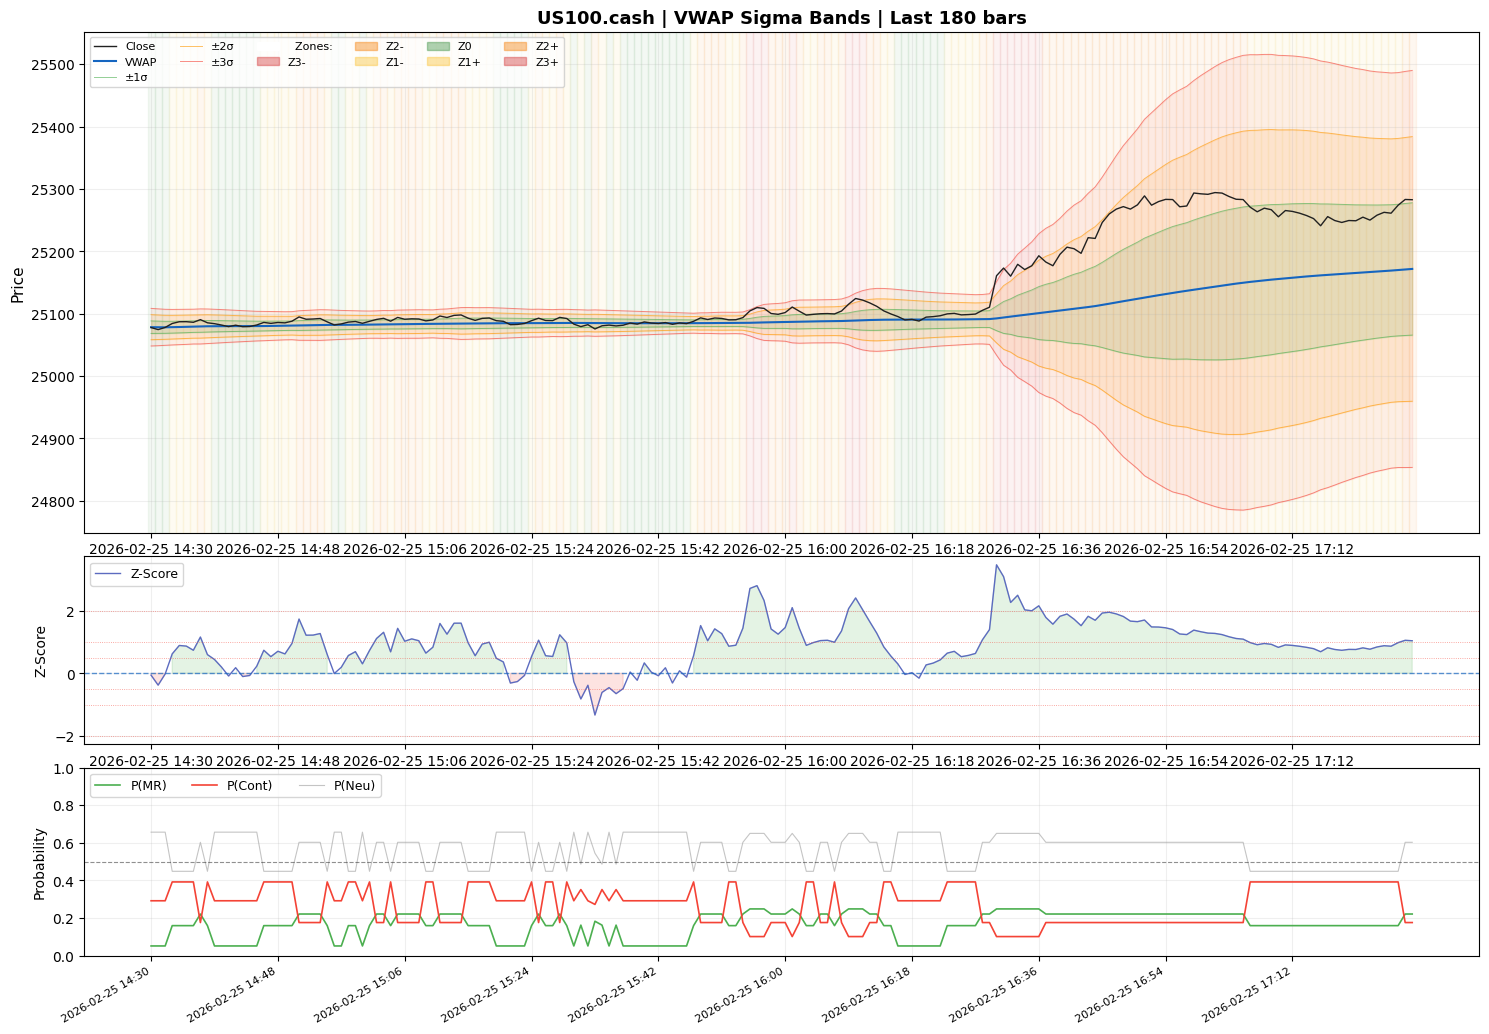

✅ Chart saved to band_overlay.png


In [43]:
# ── Render the chart ──
plot_band_overlay(results, CONFIG, n_bars=CONFIG['plot_last_n_bars'])

---
### Section 15 — Probability Table Analysis

Visual inspection of the calibrated probability table — a heatmap showing
P(MR) across zones and trend context. This is the key research output:
which zones have the strongest mean-reversion edge, and does trend context matter?

Heatmap: P(MR) by zone


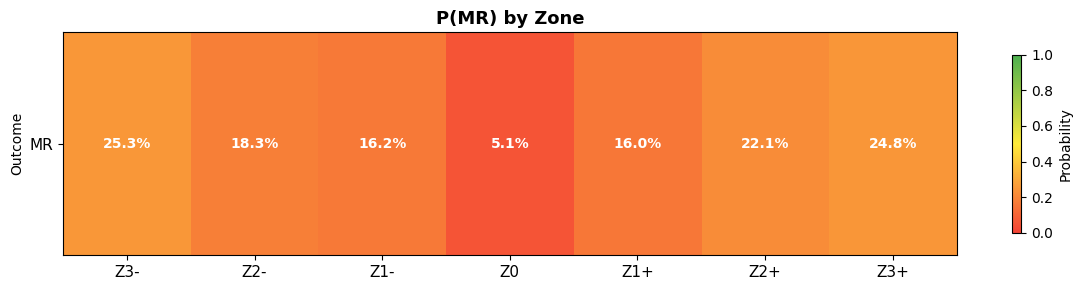

Heatmap: P(MR) by zone × trend


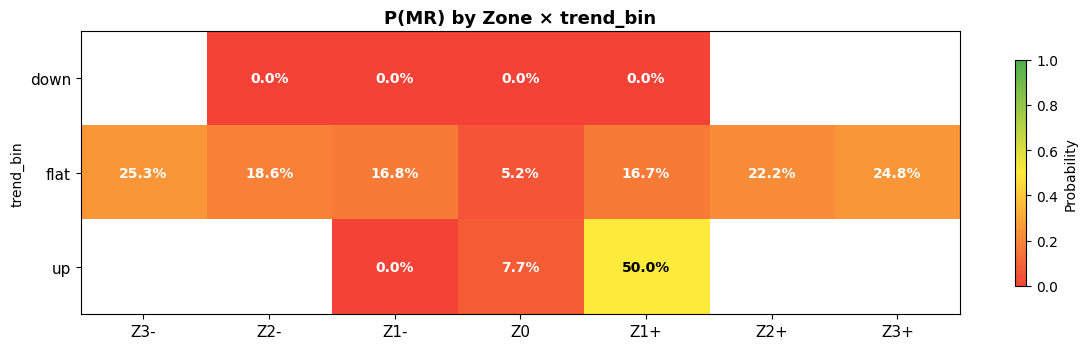

In [44]:
# ── Marginal MR probability heatmap ──
print("Heatmap: P(MR) by zone")
plot_probability_heatmap(prob_table, outcome='MR')

# ── Conditioned on trend ──
print("Heatmap: P(MR) by zone × trend")
plot_probability_heatmap(prob_table_trend, outcome='MR', context_col='trend_bin')

### Section 16 — Save Artifacts and Export

Save the calibrated probability tables, backtest results, walk-forward logs, and metadata to disk so they can be reused without rerunning the entire research notebook.

This section also exports a minimal live-use package for the MT5 workflow.

In [45]:
save_artefacts(
    prob_table=prob_table,
    prob_table_trend=prob_table_trend,
    results=results,
    CONFIG=CONFIG,
    df_cal=df_cal,
    df_val=df_val,
    df_tst=df_tst,
    wf_log=wf_log,
    artefacts_dir="artifacts",
)

print("\nTo load later:")
print("  import pandas as pd")
print("  prob_table = pd.read_parquet('artifacts/tables/prob_table_marginal.parquet')")

✅ Artefacts saved to /artifacts/:
   artifacts/metadata/config.json                                    1.2 KB
   artifacts/metadata/split_meta.json                                0.2 KB
   artifacts/tables/backtest_results.parquet                         436.3 KB
   artifacts/tables/prob_table_marginal.parquet                      5.5 KB
   artifacts/tables/prob_table_trend.parquet                         6.4 KB

To load later:
  import pandas as pd
  prob_table = pd.read_parquet('artifacts/tables/prob_table_marginal.parquet')


In [46]:
# Export minimal live-use artifacts
export_live_artefacts(
    prob_table=prob_table,
    CONFIG=CONFIG,
    export_dir="live_artifacts",
)

✅ Exported live artifacts:
 - live_artifacts\exports\zone_probabilities.csv
 - live_artifacts\exports\config.json


## Section 19 — Function Reference and Export Guide

This project uses shared `src/` modules rather than treating the notebook as the source of reusable functions.

The research notebook orchestrates the workflow, while reusable logic lives in the Python modules listed below.

### Function summary

| Function / Module | Section | File | Used in |
|---|---:|---|---|
| `load_mt5_csv(path)` | 1 | `src/loaders.py` | Backtest |
| `load_mt5_live(symbol, timeframe_mt5, n_bars)` | 13 / 18 | `src/loaders.py` | Live |
| `fetch_mt5_history(symbol, timeframe_mt5, lookback_days, ...)` | 13 | `src/loaders.py` | Live / data backfill |
| `load_tradingview_csv(path)` | 1 / 12 | `src/loaders.py` | Backtest / Replay |
| `load_generic_csv(path, column_map, ...)` | 1 | `src/loaders.py` | Backtest |
| `assign_sessions(df, sessions)` | 1 / 12 / 13 | `src/loaders.py` | Backtest / Replay / Live |
| `compute_reference(df, config)` | 3 | `src/reference.py` | All batch workflows |
| `compute_sigma(df, config)` | 4 | `src/sigma.py` | All batch workflows |
| `compute_bands(df, sigma)` | 4 | `src/sigma.py` | All batch workflows |
| `compute_zscore(df)` | 5 | `src/zones.py` | All |
| `classify_zone(z, thresholds)` | 5 | `src/zones.py` | All |
| `classify_zones_series(zscore_series, thresholds)` | 5 | `src/zones.py` | All |
| `compute_context(df, config)` | 6 | `src/context.py` | All batch workflows |
| `label_outcomes(df, config, mode)` | 7 | `src/labelling.py` | Backtest only |
| `split_by_date(df, config)` | 8a | `src/splits.py` | Backtest only |
| `wilson_ci(count, total, confidence)` | 8 | `src/calibration.py` | Backtest only |
| `calibrate_probability_table(df, config, context_col)` | 8 | `src/calibration.py` | Backtest only |
| `lookup_probabilities(zone, prob_table, marginal_table, context, config)` | 9 | `src/lookup.py` | Backtest / Replay / Live |
| `EngineState` | 10 | `src/engine.py` | Backtest / Replay / Live |
| `update_engine_state(state, bar, config, prob_table, marginal_table)` | 10 | `src/engine.py` | Backtest / Replay / Live |
| `SignalResult` | 10a | `src/signals.py` | Backtest / Live |
| `generate_signal(state, config)` | 10a | `src/signals.py` | Backtest / Live |
| `regime_gate(signal, config)` | 10a | `src/signals.py` | Backtest / Live |
| `apply_filters(signal, state, config)` | 10a | `src/signals.py` | Backtest / Live |
| `walk_forward_eval(...)` | 10b | `src/walk_forward.py` | Backtest validation |
| `evaluate_signals(log, config)` | 10c | `src/evaluation.py` | Backtest analysis |
| `run_backtest(...)` | 11 | `src/evaluation.py` | Backtest |
| `run_replay(...)` | 12 | `src/replay.py` | Replay |
| `run_live(...)` | 18 | `src/live_runner.py` | Live |
| `plot_band_overlay(results, config, ...)` | 14 | `src/plotting.py` | Research |
| `plot_probability_heatmap(prob_table, outcome, context_col)` | 15 | `src/plotting.py` | Research |
| `save_artefacts(...)` | 16 | `src/exports.py` | Research / export |
| `export_live_artefacts(...)` | 16 | `src/exports.py` | Live preparation |
| `write_mql5_overlay(...)` | 17 | `src/mql5_overlay.py` | Live |

### Notebook / file split

- `notebooks/backtest_research.ipynb` contains the research flow, diagnostics, plots, and export steps.
- `notebooks/replay_tradingview.ipynb` contains the replay-only step-through workflow for TradingView-exported data.
- `notebooks/live_trading.ipynb` contains MT5 live setup, overlay generation, and live execution workflow.
- Reusable logic is stored in `src/` modules and imported into the notebooks.

### Assumptions and known limitations

1. **Tick volume is a proxy** — MT5 tick volume correlates with real volume but can behave differently during news and thin sessions.
2. **Probability table is static in live mode** — recalibrate periodically; the live engine does not update probabilities mid-session.
3. **Outcome labels use future data** — Section 7 is backtest-only and must never be used in live or replay workflows.
4. **Low-count zones require caution** — cells below the minimum sample threshold should be treated as informational, not decisive.
5. **Regime change risk exists** — probabilities calibrated on one market regime may weaken when volatility structure changes.
6. **TradingView forex volume is often zero** — prefer `reference_type = 'TWAP'` when volume is unavailable or unreliable.
7. **MQL5 overlay is a rendering layer only** — it reads Python output and does not perform model calculations itself.